In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# загружаем очищенный датасет
df = pd.read_csv('merged_data.csv')
df.head(10)

,id_user,mon,cnt_group,cnt_indiv,sum_group,sum_indiv,cnt_total,sum_total,min_mon,max_mon,city,age,gender
0,1000,2023-03,0,2,0,3600,2,3600,2023-03,2023-12,СПб,44.0,female
1,1000,2023-04,0,4,0,7200,4,7200,2023-03,2023-12,СПб,44.0,female
2,1000,2023-05,0,4,0,6400,4,6400,2023-03,2023-12,СПб,44.0,female
3,1000,2023-06,0,2,0,3600,2,3600,2023-03,2023-12,СПб,44.0,female
4,1000,2023-07,0,4,0,7200,4,7200,2023-03,2023-12,СПб,44.0,female
5,1000,2023-08,0,3,0,5400,3,5400,2023-03,2023-12,СПб,44.0,female
6,1000,2023-09,0,4,0,7200,4,7200,2023-03,2023-12,СПб,44.0,female
7,1000,2023-11,0,5,0,9000,5,9000,2023-03,2023-12,СПб,44.0,female
8,1000,2023-12,0,5,0,9000,5,9000,2023-03,2023-12,СПб,44.0,female
9,1001,2023-01,12,2,9600,3600,14,13200,2023-01,2023-12,Москва,35.0,female


### Пользователи с 70%+ инд.тренировок

In [3]:
df_agg = df.groupby(['id_user', 'city', 'gender']).agg({'mon':'count',
                                                        'cnt_indiv':'sum',
                                                        'cnt_total':'sum',
                                                        'sum_total':'sum'}).reset_index().rename(columns = {'mon':'nmonths'})
df_agg.head()

,id_user,city,gender,nmonths,cnt_indiv,cnt_total,sum_total
0,1000,СПб,female,9,33,33,58600
1,1001,Москва,female,11,23,129,124800
2,1002,Москва,male,11,64,128,166000
3,1004,Екатеринбург,male,9,18,18,32000
4,1005,СПб,female,2,7,7,12600


In [4]:
df_agg['avg_check_per_mon'] = df_agg['sum_total']/df_agg['nmonths']

In [5]:
df_agg['share_indiv'] = df_agg['cnt_indiv']/df_agg['cnt_total']

In [6]:
df_agg['avg_train_per_mon'] = df_agg['cnt_total']/df_agg['nmonths']

In [7]:
df_indiv = df_agg[df_agg['share_indiv'] > 0.7].reset_index(drop=True)
user_ind70 = df_indiv.groupby(['city', 'gender']).agg(cnt_users = ('id_user', 'nunique'),\
                                                      avg_check = ('avg_check_per_mon', 'mean'), \
                                                      avg_train = ('avg_train_per_mon','mean')).reset_index()
user_ind70.head(10)

,city,gender,cnt_users,avg_check,avg_train
0,Екатеринбург,female,12,5391.746032,3.009524
1,Екатеринбург,male,12,5832.394180,3.256184
2,Казань,female,8,6297.500000,3.756250
3,Казань,male,12,5229.378307,2.931548
4,Москва,female,118,5565.425624,3.141311
5,Москва,male,59,6915.316115,3.872733
6,СПб,female,32,6093.278770,3.399777
7,СПб,male,28,5024.889456,2.821443


### Топ-10 клиентов

In [8]:
df_gr = df.groupby('id_user').agg({'cnt_total':'sum'}).reset_index().sort_values('cnt_total', ascending = False).head(10)
user_lst = df_gr['id_user'].tolist()
unique_df_top = df[df['id_user'].isin(user_lst)].drop_duplicates('id_user')
unique_df_top

,id_user,mon,cnt_group,cnt_indiv,sum_group,sum_indiv,cnt_total,sum_total,min_mon,max_mon,city,age,gender
9,1001,2023-01,12,2,9600,3600,14,13200,2023-01,2023-12,Москва,35.0,female
20,1002,2023-02,4,8,3200,14400,12,17600,2023-02,2023-12,Москва,34.0,male
76,1013,2023-01,10,4,8000,7200,14,15200,2023-01,2023-11,Москва,43.0,male
990,1194,2023-01,8,6,6400,10800,14,17200,2023-01,2023-12,СПб,27.0,female
1805,1381,2023-01,10,8,8000,14400,18,22400,2023-01,2023-12,Москва,25.0,female
2368,1506,2023-01,8,5,6400,9000,13,15400,2023-01,2023-10,Москва,29.0,female
2686,1570,2023-02,14,0,11200,0,14,11200,2023-02,2023-12,Екатеринбург,39.0,male
2751,1582,2023-04,10,5,8000,9000,15,17000,2023-04,2023-12,Екатеринбург,37.0,male
3093,1657,2023-01,12,2,9600,3600,14,13200,2023-01,2023-11,СПб,27.0,male
4299,1929,2023-01,11,1,8800,1800,12,10600,2023-01,2023-12,Москва,32.0,male


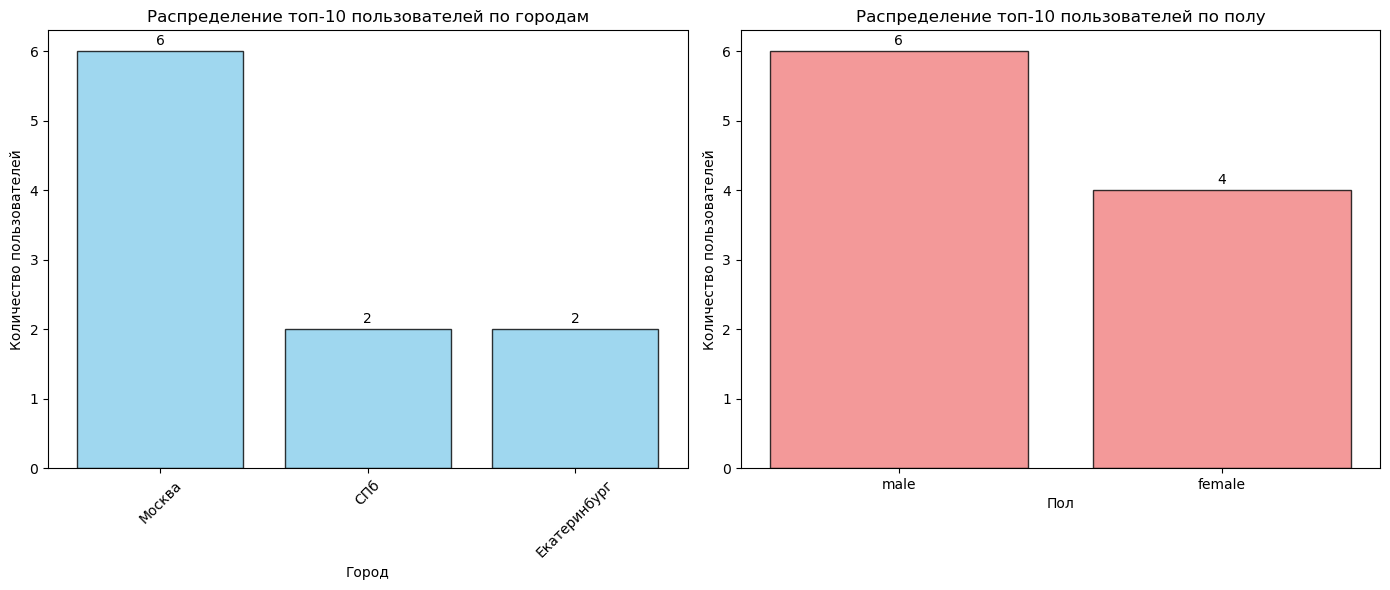

In [9]:
# Распределение по городам
city_counts = unique_df_top['city'].value_counts()
# Распределение по полу
gender_counts = unique_df_top['gender'].value_counts()
# Создаём фигуру с двумя гистограммами
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
# Гистограмма 1: распределение по городам
axes[0].bar(city_counts.index, city_counts.values, color='skyblue', edgecolor='black', alpha=0.8)
axes[0].set_title('Распределение топ‑10 пользователей по городам')
axes[0].set_xlabel('Город')
axes[0].set_ylabel('Количество пользователей')
axes[0].tick_params(axis='x', rotation=45)
# Добавляем значения над столбцами
for i, v in enumerate(city_counts.values):
    axes[0].text(i, v + 0.05, str(v), ha='center', va='bottom')
# Гистограмма 2: распределение по полу
axes[1].bar(gender_counts.index, gender_counts.values, color='lightcoral', edgecolor='black', alpha=0.8)
axes[1].set_title('Распределение топ‑10 пользователей по полу')
axes[1].set_xlabel('Пол')
axes[1].set_ylabel('Количество пользователей')
# Добавляем значения над столбцами
for i, v in enumerate(gender_counts.values):
    axes[1].text(i, v + 0.05, str(v), ha='center', va='bottom')
plt.tight_layout()
plt.show()

### Динамика клиентской базы

In [12]:
# Находим минимальный месяц для каждого клиента (когда впервые появился)
new_clients = df.groupby('id_user').agg({'mon': 'min'}).reset_index()
new_clients_count = new_clients.groupby('mon')['id_user'].nunique().reset_index(name='new_clients')
# Находим максимальный месяц для каждого клиента (когда в последний раз был активен)
gone_clients = df.groupby('id_user').agg({'mon': 'max'}).reset_index()
gone_clients_count = gone_clients.groupby('mon')['id_user'].nunique().reset_index(name='gone_clients')
# Считаем уникальных активных клиентов по каждому месяцу
active_clients = df.groupby('mon')['id_user'].nunique().reset_index(name='active_clients')
# Объединяем все датафреймы по полю mon
final_df = pd.merge(new_clients_count, gone_clients_count, on='mon', how='outer')
final_df = pd.merge(final_df, active_clients, on='mon', how='outer')
print(final_df)

        mon  new_clients  gone_clients  active_clients
0   2023-01          337            15             337
1   2023-02           88            22             350
2   2023-03           83            37             355
3   2023-04           62            21             345
4   2023-05           57            21             360
5   2023-06           51            13             383
6   2023-07           48            33             412
7   2023-08           35            33             423
8   2023-09           28            55             429
9   2023-10           27           101             441
10  2023-11           10           130             399
11  2023-12           12           357             357


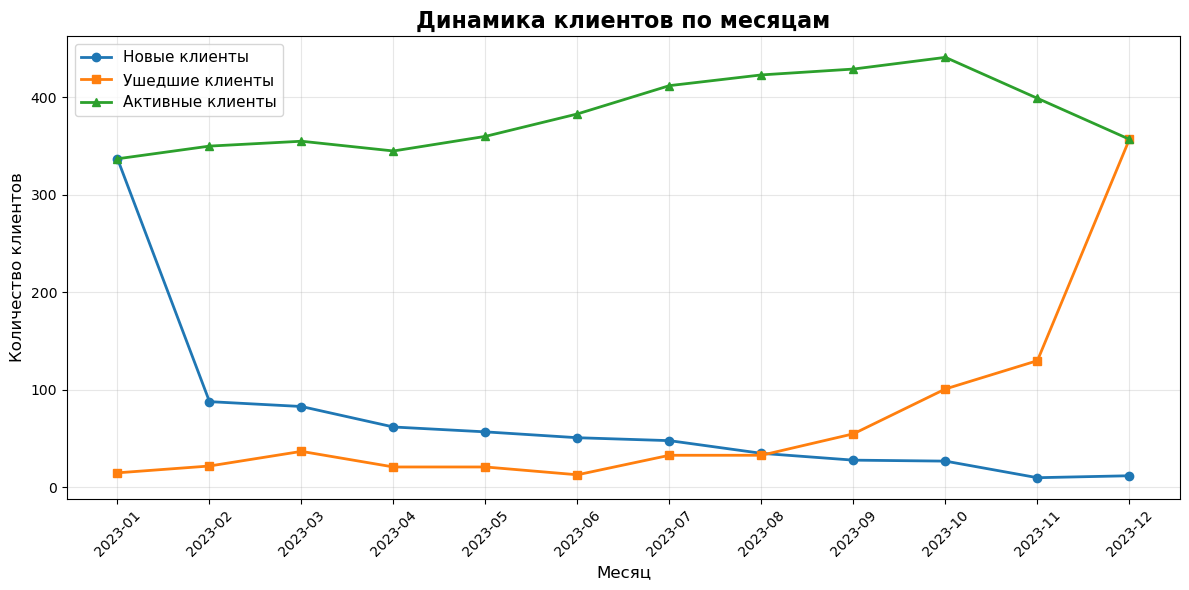

In [13]:
# Настройка размера графика
plt.figure(figsize=(12, 6))
# Построение трёх линий
plt.plot(final_df['mon'], final_df['new_clients'], 
         label='Новые клиенты', marker='o', linewidth=2)
plt.plot(final_df['mon'], final_df['gone_clients'], 
         label='Ушедшие клиенты', marker='s', linewidth=2)
plt.plot(final_df['mon'], final_df['active_clients'], 
         label='Активные клиенты', marker='^', linewidth=2)
# Настройка заголовка и подписей осей
plt.title('Динамика клиентов по месяцам', fontsize=16, fontweight='bold')
plt.xlabel('Месяц', fontsize=12)
plt.ylabel('Количество клиентов', fontsize=12)
# Добавление сетки для удобства чтения графика
plt.grid(True, alpha=0.3)
# Легенда
plt.legend(fontsize=11)
# Обеспечение читаемости меток на оси X (если месяцев много)
plt.xticks(final_df['mon'], rotation=45)
# Автоматическое выравнивание элементов графика
plt.tight_layout()
# Отображение графика
plt.show()